# 第22篇｜Seaborn 入门：一行代码出统计图

> 这是「数据分析从入门到精通」系列的第 22 篇。Matplotlib 打好了基础，这篇来认识一个更"省力"的可视化库——Seaborn。一行代码搞定统计图，还自带配色方案，做探索性分析的最佳搭档。

---

嗨，我是小荷～

Matplotlib 功能强大，但写起来有点繁琐——画一个箱线图要好多行代码。

Seaborn 是专门为数据分析设计的可视化库，建立在 Matplotlib 之上，**天生好看，一行代码出统计图**。

如果说 Matplotlib 是萧何——需要精细调度才能出效果，那 Seaborn 就像是萧何手下的精兵强将，接到命令直接就干，效率高，结果好。

---

## 一、Seaborn 的安装与配置

先把环境装好、配好，后面写代码才不会报错：


In [1]:
# 安装
# pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

# 设置全局主题（推荐这几个）
sns.set_theme(style='whitegrid')     # 白色网格，最常用
# sns.set_theme(style='white')       # 纯白，最简洁
# sns.set_theme(style='darkgrid')    # 深色网格
# sns.set_theme(style='ticks')       # 带刻度线，适合论文

# 字体大小
sns.set_context('notebook', font_scale=1.1)   # 'paper', 'notebook', 'talk', 'poster'


---

## 二、分布图：histplot + kdeplot

### 直方图

直方图是最基础的数据分布可视化，先看直方图：


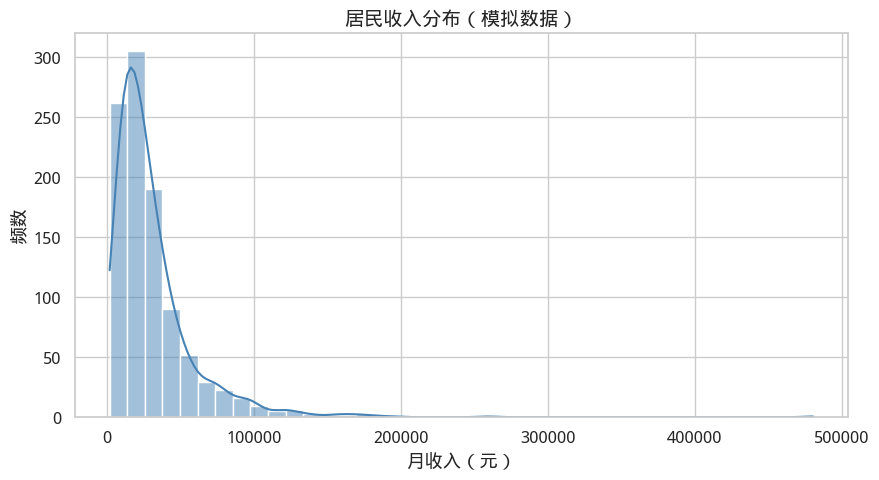

In [3]:
np.random.seed(42)
income = np.random.lognormal(mean=10, sigma=0.8, size=1000)  # 对数正态分布模拟收入

fig, ax = plt.subplots(figsize=(9, 5))
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
sns.histplot(income, bins=40, kde=True, color='steelblue', ax=ax)


ax.set_title('居民收入分布（模拟数据）', fontsize=14, fontweight='bold')
ax.set_xlabel('月收入（元）')
ax.set_ylabel('频数')
plt.tight_layout()
plt.show()


`kde=True` 会同时画出核密度估计曲线，直方图+KDE 是分析分布形态的标准搭配。

---

### 核密度图：kdeplot

KDE（核密度估计）是直方图的"平滑版"，不用纠结分箱数：


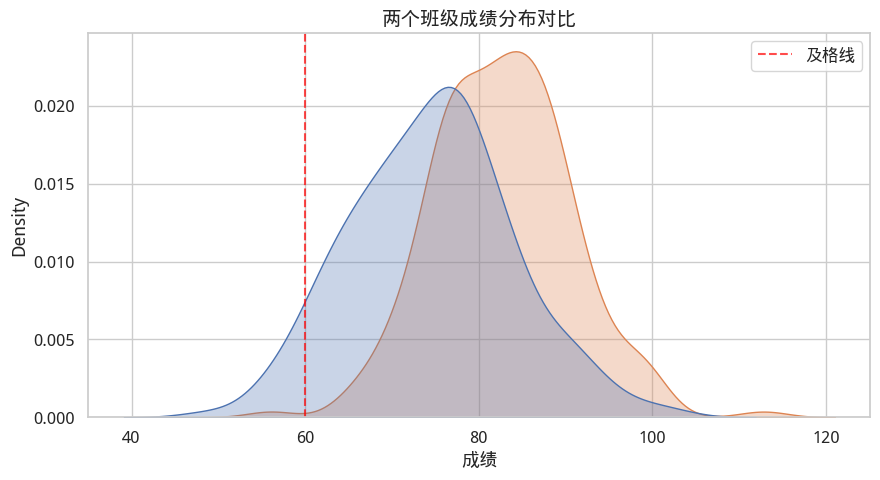

In [4]:
np.random.seed(42)
df_score = pd.DataFrame({
    '成绩': np.concatenate([
        np.random.normal(75, 10, 200),  # 班级A
        np.random.normal(82, 8, 200)    # 班级B
    ]),
    '班级': ['A班'] * 200 + ['B班'] * 200
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=df_score, x='成绩', hue='班级', fill=True, alpha=0.3, ax=ax)

ax.set_title('两个班级成绩分布对比', fontsize=14, fontweight='bold')
ax.axvline(x=60, color='red', linestyle='--', alpha=0.7, label='及格线')
ax.legend()
plt.tight_layout()
plt.show()


---

## 三、箱线图：boxplot

箱线图能一眼看到中位数、四分位和异常值，是分布分析的利器：


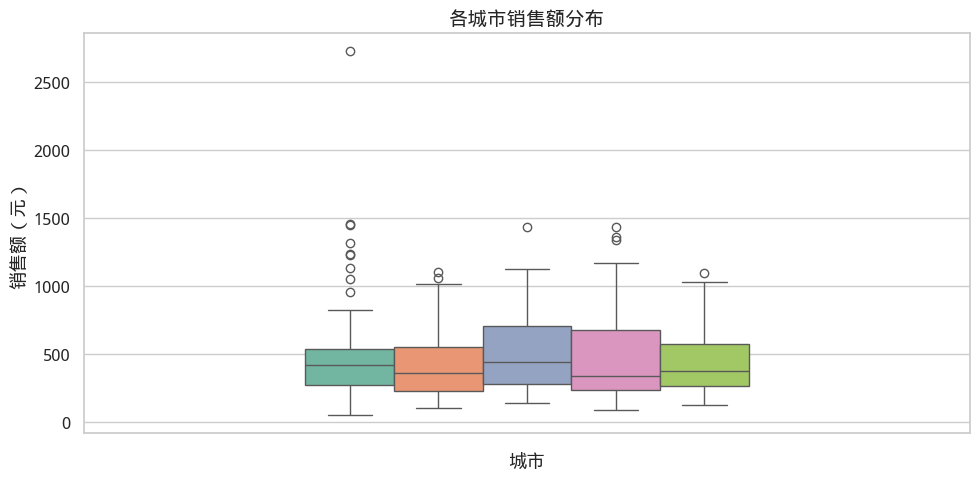

In [6]:
np.random.seed(42)
n = 300
df_sales = pd.DataFrame({
    '城市':   np.random.choice(['北京', '上海', '广州', '深圳', '成都'], n),
    '销售额': np.random.lognormal(6, 0.6, n)
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_sales, hue='城市', y='销售额',
             palette='Set2', width=0.5, legend=False,ax=ax)

ax.set_title('各城市销售额分布', fontsize=14, fontweight='bold')
ax.set_xlabel('城市')
ax.set_ylabel('销售额（元）')
plt.tight_layout()
plt.show()


箱线图一眼可以看出：中位数、四分位数、异常值（超出须线的点）。

---

## 四、热力图：heatmap

热力图最适合展示**相关矩阵**或**透视表**：


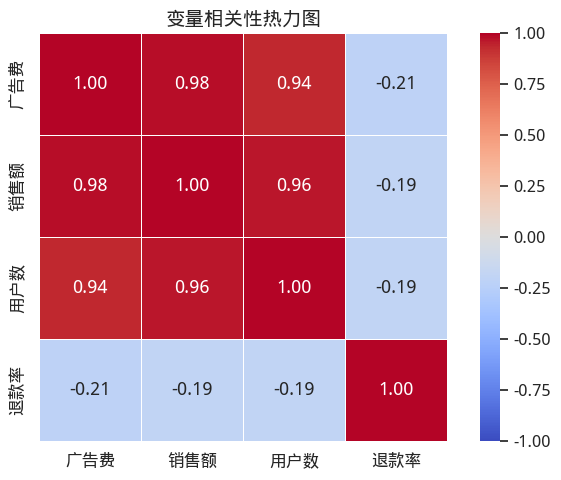

In [7]:
# 相关矩阵热力图
np.random.seed(42)
df_corr = pd.DataFrame({
    '广告费':  np.random.uniform(10, 100, 100),
    '销售额':  np.random.uniform(50, 500, 100),
    '用户数':  np.random.uniform(100, 1000, 100),
    '退款率':  np.random.uniform(0, 0.2, 100)
})
df_corr['销售额'] = df_corr['广告费'] * 3.5 + np.random.normal(0, 20, 100)
df_corr['用户数'] = df_corr['销售额'] * 2 + np.random.normal(0, 50, 100)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix,
             annot=True,         # 显示数值
             fmt='.2f',          # 保留2位小数
             cmap='coolwarm',    # 色系
             vmin=-1, vmax=1,    # 颜色范围
             center=0,           # 0值对应中间颜色
             square=True,        # 格子为正方形
             linewidths=0.5,     # 格子间隔线
             ax=ax)

ax.set_title('变量相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 五、条形图与计数图：barplot / countplot

barplot 画均值+误差棒，countplot 直接数频次，分类变量可视化就用这俩：


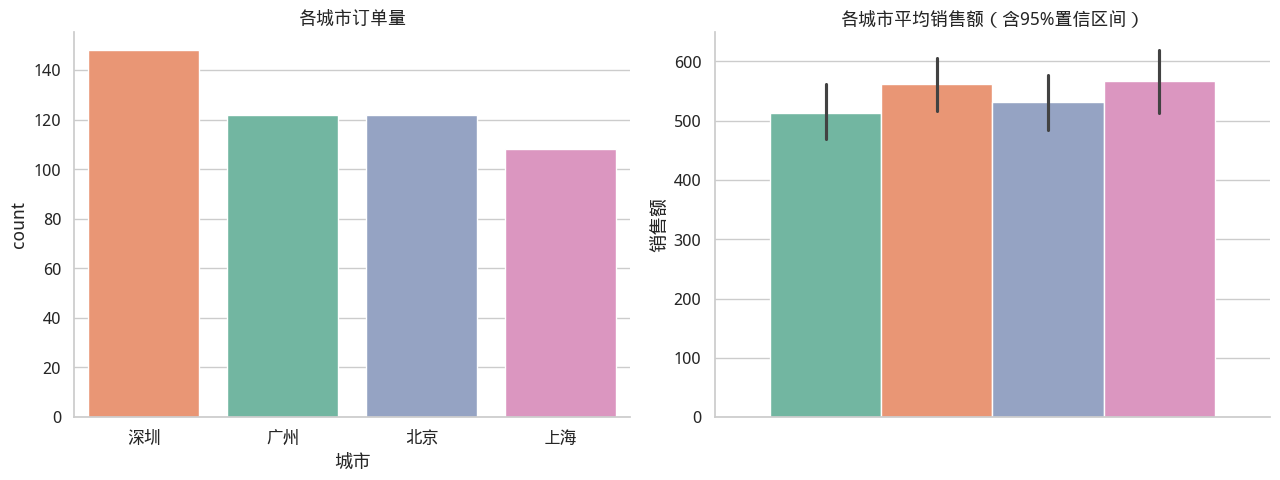

In [16]:
np.random.seed(42)
n = 500
df = pd.DataFrame({
    '城市':  np.random.choice(['北京', '上海', '广州', '深圳'], n),
    '品类':  np.random.choice(['数码', '服装', '食品'], n),
    '销售额': np.random.randint(100, 1000, n)
})

# countplot：统计每个类别出现次数
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='城市', hue='城市',palette='Set2', 
              order=df['城市'].value_counts().index, 
              ax=axes[0],legend=False,)
axes[0].set_title('各城市订单量', fontsize=13, fontweight='bold')

# barplot：计算均值+误差棒
sns.barplot(data=df, hue='城市', y='销售额', palette='Set2',
             estimator='mean', errorbar='ci', legend=False,ax=axes[1])
axes[1].set_title('各城市平均销售额（含95%置信区间）', fontsize=13, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---

## 六、散点图矩阵：pairplot

`pairplot` 是 Seaborn 最强功能之一，一行代码看所有变量的两两关系：


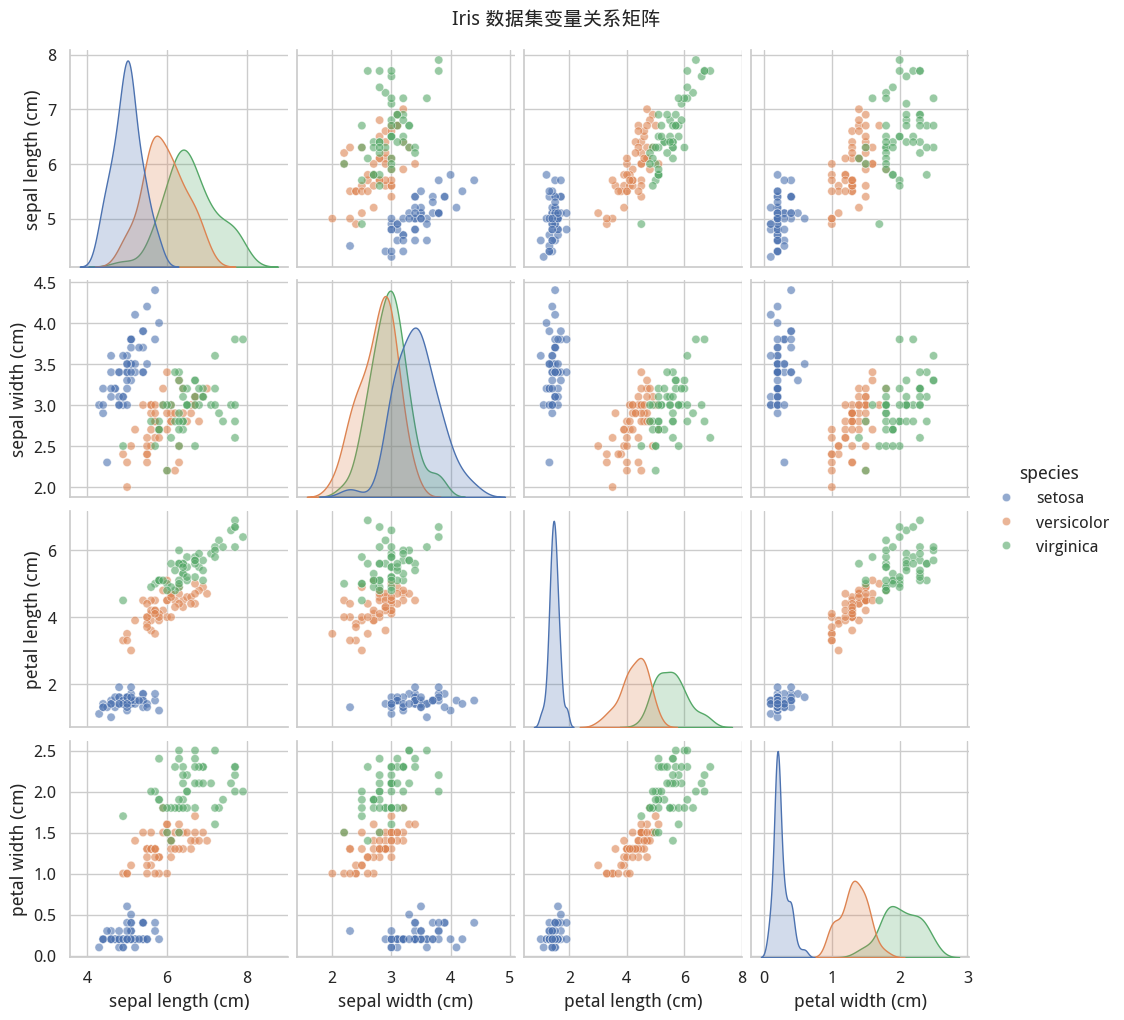

In [15]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑

iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = [iris.target_names[i] for i in iris.target]

sns.pairplot(df_iris, hue='species', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Iris 数据集变量关系矩阵', y=1.02, fontsize=14, fontweight='bold')
plt.show()


对角线是各变量的分布，非对角线是两两散点图，同时按 `hue` 着色——这个图在做探索性分析时非常常用。

---

## 七、🔧 综合实战：三合一分析图

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


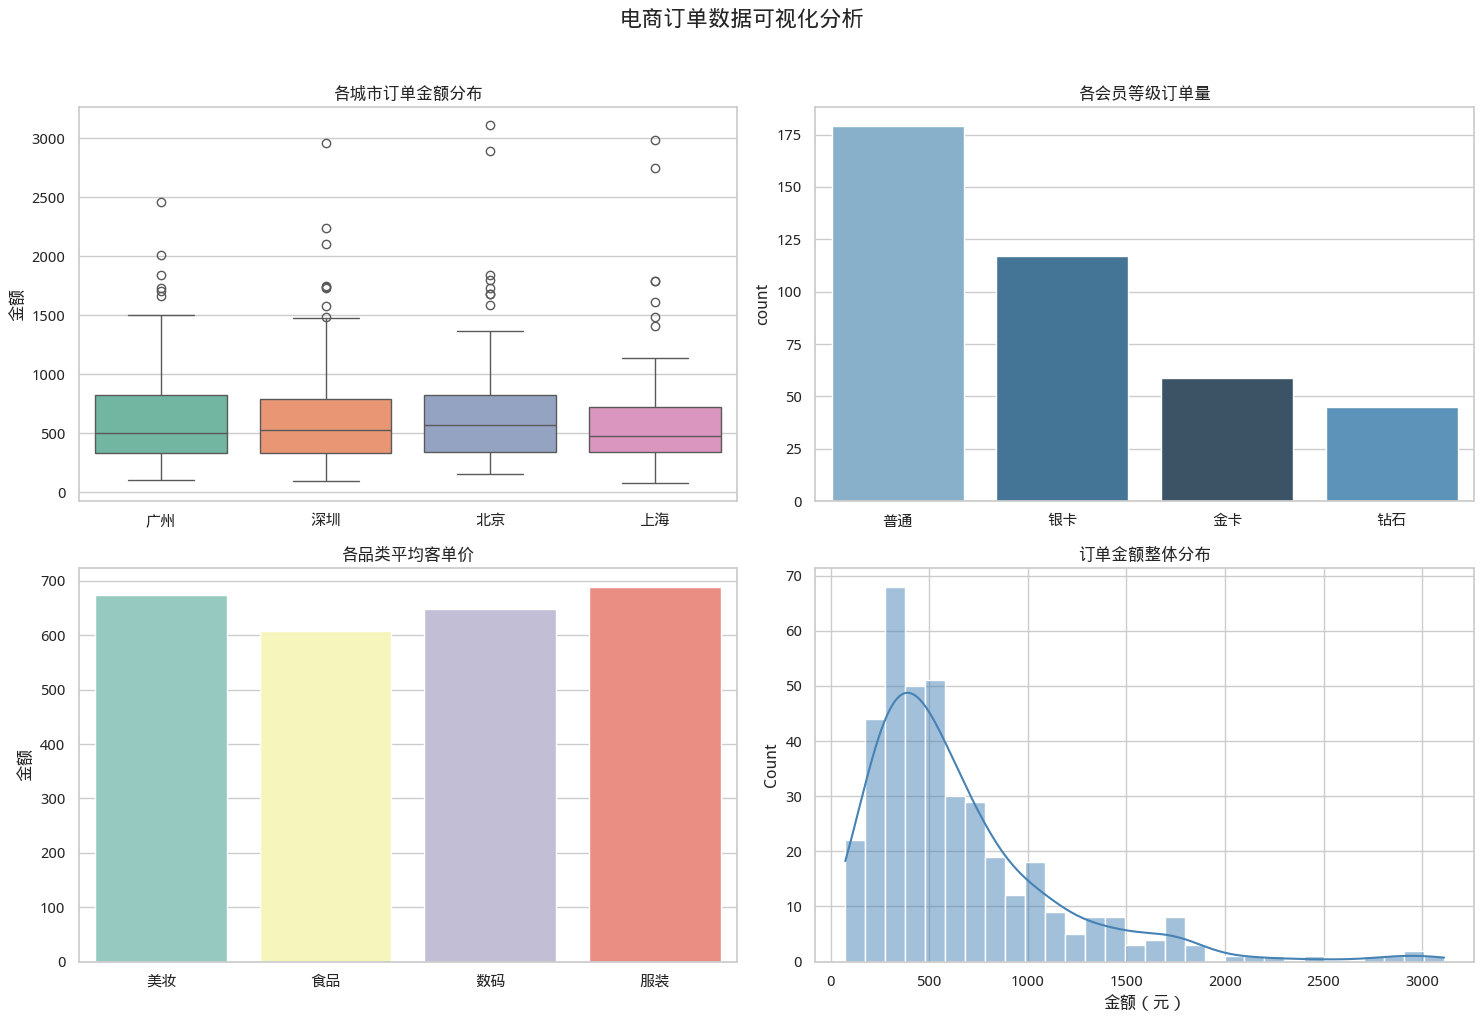

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(42)
n = 400
df = pd.DataFrame({
    '城市':   np.random.choice(['北京', '上海', '广州', '深圳'], n),
    '品类':   np.random.choice(['数码', '服装', '食品', '美妆'], n),
    '会员':   np.random.choice(['普通', '银卡', '金卡', '钻石'], n, p=[0.45, 0.3, 0.15, 0.1]),
    '金额':   np.random.lognormal(6.2, 0.7, n)
})

fig = plt.figure(figsize=(15, 10))
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
# ── 子图1：各城市金额分布（箱线图）──
ax1 = fig.add_subplot(2, 2, 1)
sns.boxplot(data=df, x='城市', hue='城市',y='金额', palette='Set2', ax=ax1,legend=False)
ax1.set_title('各城市订单金额分布', fontweight='bold')
ax1.set_xlabel('')

# ── 子图2：会员等级订单数量（countplot）──
ax2 = fig.add_subplot(2, 2, 2)
order = ['普通', '银卡', '金卡', '钻石']
sns.countplot(data=df, x='会员', hue='会员',  order=order, palette='Blues_d', ax=ax2,legend=False)
ax2.set_title('各会员等级订单量', fontweight='bold')
ax2.set_xlabel('')

# ── 子图3：品类订单金额均值（barplot）──
ax3 = fig.add_subplot(2, 2, 3)
sns.barplot(data=df, x='品类', hue='品类', y='金额', palette='Set3',
             estimator='mean', errorbar=None, ax=ax3,legend=False)
ax3.set_title('各品类平均客单价', fontweight='bold')
ax3.set_xlabel('')

# ── 子图4：金额分布（histplot）──
ax4 = fig.add_subplot(2, 2, 4)
sns.histplot(df['金额'], bins=30, kde=True, color='steelblue', ax=ax4)
ax4.set_title('订单金额整体分布', fontweight='bold')
ax4.set_xlabel('金额（元）')

plt.suptitle('电商订单数据可视化分析', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('seaborn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 八、Seaborn vs Matplotlib 对比

| 特点 | Seaborn | Matplotlib |
|------|---------|------------|
| 上手难度 | 简单 | 中等 |
| 默认美观度 | 高 | 低 |
| 灵活性 | 中等 | 高 |
| 统计图表 | 原生支持 | 需要手写 |
| 自定义程度 | 受限 | 无限 |
| 最适合 | 快速探索分析 | 精细定制图表 |

实际工作中两个配合用：Seaborn 快速探索，Matplotlib 精细调整。

---

## 九、📋 Seaborn 常用图表速查

| 图表 | 函数 | 适用场景 |
|------|------|---------|
| 直方图 | `histplot` | 单变量分布 |
| 核密度图 | `kdeplot` | 分布形态对比 |
| 箱线图 | `boxplot` | 分布+异常值 |
| 热力图 | `heatmap` | 相关矩阵/透视表 |
| 条形图 | `barplot` | 分组均值+误差 |
| 计数图 | `countplot` | 分类频次 |
| 散点图矩阵 | `pairplot` | 多变量关系探索 |
| 小提琴图 | `violinplot` | 分布形态更精细 |

---

## 十、📝 小结

Seaborn 三大优势：
1. **天生好看**：默认样式就比 Matplotlib 美观
2. **统计能力内置**：箱线图、误差棒、KDE 一行搞定
3. **与 Pandas 深度集成**：直接传 DataFrame 就能画

---

## 十一、🏋️ 课后练习

1. 用 Seaborn 对你在第18篇实战里的 `full` 大宽表画一张热力图，展示各变量相关性。
2. 画一张箱线图，比较不同会员等级的消费金额分布。
3. 用 `pairplot` 探索 `amount`、`quantity`、`discount` 三个变量之间的关系。

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 23 篇：分布探索 — 直方图 / KDE / 箱线图 / 小提琴图**
>
> 下篇深入讲解分布探索——学完之后，对任何一份新数据，你都能在 5 分钟内摸清它的「体型」。

---

*跟着小荷，数据分析路上不迷路～*
